# Switching Performance

**RQ3.** What does runtime model switching cost, and what does it save?

Two cases, identical loop, only the plant exchanged:

- **Full FEM** — the deformable model drives the whole horizon. The reference.
- **Switched FEM/FMU** — the region map hands the horizon between the two models.

Both run `HybridAlgorithm` and therefore pay the same detection overhead. Without
contact the baseline has no indicator of its own, so it is given a constant,
never-crossing one; otherwise it would fall back to `GaussSeidelAlgorithm`, take
no trial advance at all, and the switched case would be charged for work the
reference never does.

Set `CONTACT` below to select the regime. Both were previously separate notebooks
that shared 25 definitions by copy.

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().resolve().parents[0] / "notebooks"))
sys.path.insert(0, str(Path.cwd().resolve()))

from evidence import repo_root

REPO = repo_root()

import evidence as ev
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)

plt = set_professional_style(latex=True)

print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


## Configuration

Every parameter of the run is one `Scenario`. It travels with the run and is
written next to the numbers as provenance, so a recorded result cannot be
separated from the configuration that produced it.

In [4]:
CONTACT = True
SMOKE = True

# Campaign B horizon. evidence_plan.md section 4 requires "well beyond 0.4 s";
# 2.0 is the campaign target. The 2026-09-12 trial runs this contact case once
# to price the horizon and count the contacts before the overnight campaign.
HORIZON_S = 1.0

SCENARIO = ev.CONTACT_SCENARIO if CONTACT else ev.NO_CONTACT_SCENARIO
SCENARIO = SCENARIO.replace(t_end=HORIZON_S)
if SMOKE:
    # Repetitions only. The horizon is NOT shortened: whether the mechanism
    # fires at all depends on it. With the launch gate, the region key only
    # crosses down if |theta| rises slower than gate_offset / gate_t_open
    # (~11.7 rad/s here) *and* the run lasts long enough for |theta| to come
    # back through the band. A 0.1 s smoke horizon silently produced zero
    # switches and a benchmark that measured nothing.
    SCENARIO = SCENARIO.replace(n_warmup=0, n_repeats=1)

# evidence_plan.md section 3: T2 is the runtime table, F5 the runtime
# distribution figure. Both regimes feed the same register rows, so the
# scenario is part of the filename and one does not overwrite the other.
TABLE_ID = f"T2_{SCENARIO.name}"
FIGURE_ID = f"F5_{SCENARIO.name}"
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

display(pd.Series(SCENARIO.provenance()).to_frame("value"))

,value
name,contact
contact,True
t0,0.0
t_end,2.0
macro_dt,0.001
fem_internal_dt,0.001
switch_threshold_rad,0.075
switch_band_rad,0.005
region_modes,"[FEM, FMU]"
gate_t_open_s,0.03


## Cases

The baseline is a bare `FEMPendulum`; the switched case is a `SwitchingPendulum`
with the scenario's region map installed. Everything else is shared.

In [4]:
from syssimx_examples.controlled_pendulum.components import FEMPendulum


def build_full_fem():
    plant = FEMPendulum(name=ev.PLANT_NAME, group="Plant")
    plant.set_parameters(**ev.make_fem_parameters(SCENARIO))
    ev.declare_plant_feedthrough(plant)
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Full FEM", detection_probe=True
    )
    return system, plant, {"FEM": plant}


def build_switched():
    plant = ev.SwitchingPendulum(SCENARIO, name=ev.PLANT_NAME).declare_regions()
    plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})
    ev.declare_plant_feedthrough(plant)
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Switched FEM/FMU"
    )
    return system, plant, {"FEM": plant.fem, "FMU": plant.fmu}


CASES = {"Full FEM": build_full_fem, "Switched FEM/FMU": build_switched}

## Execute

Warm-up repetitions are excluded from every summary. The first evaluated
repetition of each case is kept for the figure and the self-checks.

In [5]:
def progress(total, desc):
    return tqdm(total=total, desc=desc, unit=" sim s", leave=False)


rows, kept = [], {}
for repeat in range(SCENARIO.n_warmup):
    for name, builder in CASES.items():
        row, _ = ev.run_measured_case(
            builder, name, repeat, SCENARIO, warmup=True, progress=progress
        )
        rows.append(row)

for repeat in range(SCENARIO.n_repeats):
    for name, builder in CASES.items():
        row, result = ev.run_measured_case(
            builder, name, repeat, SCENARIO,
            keep_result=(repeat == 0), progress=progress,
        )
        rows.append(row)
        if result is not None:
            kept[name] = result

df = pd.DataFrame(rows)
df_eval = df.loc[~df["warmup"]].copy()
print(f"{len(df_eval)} evaluated runs over {SCENARIO.n_repeats} repetitions")

repeat 1 - Full FEM:   0%|          | 0/2.0 [00:00<?, ? sim s/s]

repeat 1 - Switched FEM/FMU:   0%|          | 0/2.0 [00:00<?, ? sim s/s]

2 evaluated runs over 1 repetitions


## Trajectory comparison

Deliberately placed **before** the self-checks. Those checks raise on a contact-count
mismatch, and a mismatch is exactly when the trajectory is worth looking at, so a
figure downstream of the assertion would never render on the run that needs it.

The comparison is diagnostic, not evidence. Once the self-checks pass and the run is
a campaign run, this figure is register entry F4.


In [5]:
import matplotlib.transforms as mtransforms

from plot_setup import MODEL_COLORS, REFERENCE_STYLE

# The trajectories live in kernel memory only, and this run costs about an hour
# and three quarters. Losing the kernel loses all of it, because record() keeps
# the scalars and nothing keeps theta(t). So cache the arrays on the run that
# produces them and rebuild from the cache when the kernel no longer has them.
CACHE = OUT_DIR / f"F4_{SCENARIO.name}_trajectories.npz"


def _pack(case):
    """The subset of a kept result that this figure needs, as plain arrays."""
    starts, stops, modes = zip(*case["mode_intervals"]) if case["mode_intervals"] else ((), (), ())
    return {
        "t": case["t"],
        "theta": case["theta"],
        "contact_times": np.asarray(case["contact_times"], dtype=float),
        "switch_times": np.asarray([float(e.time) for e in case["switch_events"]]),
        "interval_starts": np.asarray(starts, dtype=float),
        "interval_stops": np.asarray(stops, dtype=float),
        "interval_modes": np.asarray(modes, dtype=object),
    }


def _unpack(store, prefix):
    return {
        "t": store[f"{prefix}_t"],
        "theta": store[f"{prefix}_theta"],
        "contact_times": store[f"{prefix}_contact_times"],
        "switch_times": store[f"{prefix}_switch_times"],
        "mode_intervals": list(zip(
            store[f"{prefix}_interval_starts"],
            store[f"{prefix}_interval_stops"],
            store[f"{prefix}_interval_modes"],
        )),
    }


if "kept" in dir():
    switched = _pack(kept["Switched FEM/FMU"])
    switched["mode_intervals"] = kept["Switched FEM/FMU"]["mode_intervals"]
    baseline = _pack(kept["Full FEM"])
    baseline["mode_intervals"] = kept["Full FEM"]["mode_intervals"]
    np.savez_compressed(
        CACHE,
        **{f"switched_{k}": v for k, v in _pack(kept["Switched FEM/FMU"]).items()},
        **{f"baseline_{k}": v for k, v in _pack(kept["Full FEM"]).items()},
    )
    print(f"trajectories cached      : {CACHE.name}")
else:
    if not CACHE.exists():
        raise RuntimeError(
            f"No trajectories in this kernel and no cache at {CACHE}. "
            f"Run the Execute cell above, which takes about an hour and three "
            f"quarters at this horizon."
        )
    # Read inside the context manager. np.load on a zip archive is lazy and
    # holds the file open, which on Windows blocks the next run from
    # overwriting its own cache.
    with np.load(CACHE, allow_pickle=True) as _store:
        switched = _unpack(_store, "switched")
        baseline = _unpack(_store, "baseline")
    print(f"trajectories loaded from : {CACHE.name} (this kernel did not run them)")

# The two runs do not share a time grid. Event localization inserts steps where
# an indicator crosses, and the cases cross at different instants, so the
# difference has to be taken on a common grid rather than element-wise.
theta_base_on_sw = np.interp(switched["t"], baseline["t"], baseline["theta"])
delta = switched["theta"] - theta_base_on_sw

sw_contacts = np.asarray(switched["contact_times"], dtype=float)
base_contacts = np.asarray(baseline["contact_times"], dtype=float)

# Where do the two bounce sequences part company? Pair them in order while they
# still agree, and report the first pair that does not. That instant, not the
# count, is what a horizon decision needs.
n_pairable = min(sw_contacts.size, base_contacts.size)
paired_offset = np.abs(sw_contacts[:n_pairable] - base_contacts[:n_pairable])
gaps = np.diff(base_contacts)
mean_gap = float(np.mean(gaps)) if gaps.size else float("inf")
diverged = np.flatnonzero(paired_offset > 0.25 * mean_gap)
first_bad = int(diverged[0]) if diverged.size else None

print(f"contacts            : {base_contacts.size} full FEM, {sw_contacts.size} switched")
print(f"mean bounce gap     : {mean_gap:.4f} s")
if first_bad is None:
    print(f"paired instants     : all {n_pairable} within a quarter gap "
          f"(max {paired_offset.max():.2e} s)" if n_pairable else "paired instants     : none")
else:
    print(f"first divergence    : contact {first_bad + 1} at t = "
          f"{base_contacts[first_bad]:.4f} s, offset {paired_offset[first_bad]:.2e} s "
          f"({paired_offset[first_bad] / mean_gap:.0%} of a gap)")
print(f"max |theta| deviation: {np.abs(delta).max():.3e} rad")

fig, (ax_theta, ax_delta) = plt.subplots(
    2, 1, figsize=(FULL_WIDTH, 0.62 * FULL_WIDTH), sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)

# Which model drove the switched run, as a background band. The reader needs to
# see whether a deviation starts inside an FMU stretch or at a handover.
for t_start, t_stop, mode in switched["mode_intervals"]:
    ax_theta.axvspan(t_start, t_stop, color=MODEL_COLORS[mode], alpha=0.07, linewidth=0)

ax_theta.plot(baseline["t"], baseline["theta"], label="Full FEM", **REFERENCE_STYLE)
ax_theta.plot(switched["t"], switched["theta"], color=MODEL_COLORS["FEM"],
              linewidth=1.0, label="Switched FEM/FMU", zorder=3)
for t_switch in switched["switch_times"]:
    ax_theta.axvline(float(t_switch), color="0.35", linestyle="--", linewidth=0.7, zorder=2)
ax_theta.axhline(0.0, **{"color": "0.45", "linestyle": ":", "linewidth": 1.0})
ax_theta.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_theta.grid(True, alpha=0.4)
ax_theta.legend(loc="upper right", fontsize=7, frameon=False, ncol=2)

ax_delta.plot(switched["t"], delta, color="#C75C2D", linewidth=0.9)
ax_delta.axhline(0.0, color="0.45", linestyle=":", linewidth=1.0)
# Contact instants as rugs on opposite edges, so a desynchronizing sequence is
# visible as the two combs drifting apart rather than as a number in a table.
rug = mtransforms.blended_transform_factory(ax_delta.transData, ax_delta.transAxes)
ax_delta.plot(base_contacts, np.full(base_contacts.shape, 0.045), linestyle="none",
              marker="|", markersize=9, color="0.35", transform=rug,
              clip_on=False, label="contact, full FEM")
ax_delta.plot(sw_contacts, np.full(sw_contacts.shape, 0.955), linestyle="none",
              marker="|", markersize=9, color=MODEL_COLORS["FEM"], transform=rug,
              clip_on=False, label="contact, switched")
if first_bad is not None:
    ax_delta.axvline(base_contacts[first_bad], color="#B23A48", linewidth=1.0)
ax_delta.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_delta.set_ylabel(r"$\Delta\theta$ in $\mathrm{rad}$")
ax_delta.grid(True, alpha=0.4)

fig.tight_layout()
# Below the figure: both combs span the full width at the two edges, so any
# in-axes placement sits on one of them.
fig.legend(*ax_delta.get_legend_handles_labels(), loc="lower center",
           bbox_to_anchor=(0.5, -0.04), ncol=2, fontsize=7, frameon=False)
# The .smoke suffix mirrors record(): a reduced run must not leave a file that
# looks like the campaign figure.
_suffix = ".smoke.pdf" if SMOKE else ".pdf"
fig.savefig(OUT_DIR / f"F4_{SCENARIO.name}{_suffix}", bbox_inches="tight")
plt.show()


RuntimeError: No trajectories in this kernel and no cache at C:\Users\flori\source\repos\FlorianFrech\SystemSimulation\notebooks\figures\F4_contact_trajectories.npz. Run the Execute cell above, which takes about an hour and three quarters at this horizon.

## Self-checks

A benchmark that silently stopped exercising the mechanism still produces a
speedup number. These raise rather than warn.

In [6]:
switched = kept["Switched FEM/FMU"]
baseline = kept["Full FEM"]

if df_eval.loc[df_eval["case"] == "Switched FEM/FMU", "n_switches"].min() == 0:
    # Say why, rather than only that. The two causes are a horizon that ends
    # before the key re-enters the band, and a launch fast enough that the gated
    # key never leaves the upper region in the first place.
    key_trace = np.abs(switched["theta"]) + SCENARIO.gate_offset_rad * np.clip(
        1.0 - switched["t"] / max(SCENARIO.gate_t_open_s, 1e-12), 0.0, None
    ) if SCENARIO.gated else np.abs(switched["theta"])
    boundary_events = {
        name: len(records)
        for (_c, name), records in switched.get("event_history", {}).items()
        if name.startswith("region_boundary_")
    }
    raise AssertionError(
        "The switched case never left its initial model, so this run measures "
        "nothing about switching.\n"
        f"  reconciled initial mode : {switched['initial_mode']}\n"
        f"  horizon                 : {SCENARIO.t0} .. {SCENARIO.t_end} s\n"
        f"  region key min / max    : {key_trace.min():.4f} / {key_trace.max():.4f} rad\n"
        f"  armed edges             : {SCENARIO.armed_lower_edge:.4f} / "
        f"{SCENARIO.armed_upper_edge:.4f} rad\n"
        f"  region boundary events  : {boundary_events or 'none'}\n"
        "If the key never reaches an armed edge, either the horizon is too short "
        "or the launch is too fast for the gate: the key only crosses down while "
        "|theta| rises slower than gate_offset / gate_t_open."
    )

if SCENARIO.contact:
    counts = df_eval.groupby("case")["n_contacts"].apply(lambda s: sorted(set(s))).to_dict()
    print("contacts per case:", counts)
    if min(min(v) for v in counts.values()) == 0:
        raise AssertionError(
            "No wall contact was resolved. The pendulum starts on the wall_hit zero, so a first "
            "step onto the negative side leaves the falling indicator unable to fire (HYB-01)."
        )
    if len(baseline["contact_times"]) != len(switched["contact_times"]):
        raise AssertionError(
            f"Contact counts differ: {len(baseline['contact_times'])} vs "
            f"{len(switched['contact_times'])}. The runs are on different bounce sequences, so "
            f"any trajectory comparison would compare unlike physics."
        )
    offsets = np.abs(np.array(switched["contact_times"]) - np.array(baseline["contact_times"]))
    gaps = np.diff(baseline["contact_times"])
    mean_interval = float(np.mean(gaps)) if gaps.size else float("inf")
    print(f"max contact-instant offset : {offsets.max():.2e} s "
          f"({offsets.max() / SCENARIO.macro_dt:.1f} macro steps)")
    if offsets.max() > 0.5 * mean_interval:
        raise AssertionError("Contact instants differ by more than half the mean bounce interval.")

if SCENARIO.gated:
    # The launch gate must not drive a switch on its own. The run starts in the
    # outer region, whose armed threshold is the lower band edge, so the gated
    # key has to stay above that edge for the whole ramp.
    t = switched["t"]
    ramp = t <= SCENARIO.gate_t_open_s
    key = np.abs(switched["theta"][ramp]) + SCENARIO.gate_offset_rad * np.clip(
        1.0 - t[ramp] / SCENARIO.gate_t_open_s, 0.0, None
    )
    print(f"gated key minimum over ramp: {key.min():.4f} rad "
          f"(armed edge {SCENARIO.armed_lower_edge:.4f} rad)")
    if key.size and key.min() <= SCENARIO.armed_lower_edge:
        raise AssertionError(
            "The gated key falls to the armed edge during the ramp, so the ramp itself triggers "
            "the switch and the model choice encodes this trajectory's schedule."
        )

print("OK: the mechanism was exercised and the two cases are comparable.")

contacts per case: {'Full FEM': [20], 'Switched FEM/FMU': [24]}


AssertionError: Contact counts differ: 20 vs 24. The runs are on different bounce sequences, so any trajectory comparison would compare unlike physics.

## Result

`run_speedup` is the headline. `accepted_speedup` divides out the detection
overhead that both cases pay, and should track the inverse FEM duty cycle: if the
FEM is active for a fraction *f* of the horizon and dominates the cost, accepted
model time scales with *f*. `discarded` is the share of model time that is
computed and rolled back — a property of hybrid detection, not of switching.

In [7]:
paired = df_eval.pivot(index="repeat", columns="case", values="run_s")
ratio = paired["Full FEM"] / paired["Switched FEM/FMU"]

summary = df_eval.groupby("case", sort=False).agg(
    run_s=("run_s", "median"),
    solve_s=("solve_s", "median"),
    accepted_s=("solve_accepted_s", "median"),
    overhead_s=("overhead_s", "median"),
    fem_active_sim_s=("fem_active_sim_s", "median"),
    n_switches=("n_switches", "median"),
)
ref = summary.loc["Full FEM"]
summary["run_speedup"] = ref["run_s"] / summary["run_s"]
summary["accepted_speedup"] = ref["accepted_s"] / summary["accepted_s"]
summary["overhead_share"] = summary["overhead_s"] / summary["run_s"]
summary["fem_duty"] = summary["fem_active_sim_s"] / SCENARIO.sim_time

discarded = {
    case: float(
        sum(sub[f"solve_{p}_s"].median() for p in ev.DISCARDED_PHASES)
        / max(sub["solve_s"].median(), 1e-12)
    )
    for case, sub in df_eval.groupby("case", sort=False)
}
summary["discarded"] = pd.Series(discarded)

display(summary.style.format({
    "run_s": "{:.2f}", "solve_s": "{:.2f}", "accepted_s": "{:.2f}",
    "overhead_s": "{:.3f}", "fem_active_sim_s": "{:.3f}", "n_switches": "{:.0f}",
    "run_speedup": "{:.2f}x", "accepted_speedup": "{:.2f}x",
    "overhead_share": "{:.1%}", "fem_duty": "{:.1%}", "discarded": "{:.1%}",
}))

print(f"paired run speedup : median {ratio.median():.2f}x  "
      f"spread {ratio.max() - ratio.min():.2f}")
print(f"1 / FEM duty cycle : {1.0 / summary.loc['Switched FEM/FMU', 'fem_duty']:.2f}x "
      f"(expected accepted speedup)")

,run_s,solve_s,accepted_s,overhead_s,fem_active_sim_s,n_switches,run_speedup,accepted_speedup,overhead_share,fem_duty,discarded
case,,,,,,,,,,,
Full FEM,4329.07,4272.73,2109.31,56.344,2.000,0,1.00x,1.00x,1.3%,100.0%,50.6%
Switched FEM/FMU,2116.54,2075.16,1007.45,41.379,1.168,11,2.05x,2.09x,2.0%,58.4%,51.5%


paired run speedup : median 2.05x  spread 0.00
1 / FEM duty cycle : 1.71x (expected accepted speedup)


In [8]:
record(
    TABLE_ID,
    {
        "run_speedup_paired_median": float(ratio.median()),
        "run_speedup_paired": [float(v) for v in ratio],
        "accepted_speedup": float(summary.loc["Switched FEM/FMU", "accepted_speedup"]),
        "fem_duty_cycle": float(summary.loc["Switched FEM/FMU", "fem_duty"]),
        "overhead_share": {k: float(v) for k, v in summary["overhead_share"].items()},
        "discarded_model_time": {k: float(v) for k, v in summary["discarded"].items()},
        "n_switches": int(summary.loc["Switched FEM/FMU", "n_switches"]),
        "run_s_median": {k: float(v) for k, v in summary["run_s"].items()},
        "scenario": SCENARIO.provenance(),
    },
    directory=RESULTS,
    notebook="04_performance",
    smoke=SMOKE,
)

WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/T2_contact.smoke.json')

## Figure

One panel: where the wall time goes in each case, split by algorithm phase, with
orchestration on top. The discarded phases are what the hybrid scheme computes
and throws away; they are present with and without switching.

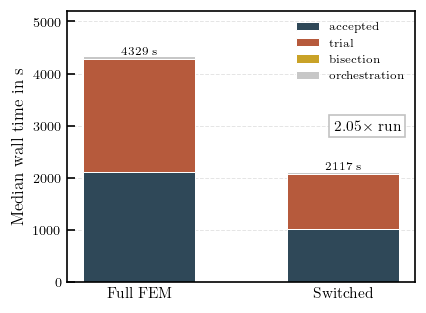

In [9]:
PHASE_COLORS = {
    ev.ACCEPTED: "#2F4858", ev.TRIAL: "#B65A3C", ev.BISECTION: "#C9A227",
    ev.EVENTS: "#7B6D8D", ev.OTHER: "#9AA5A8",
}

cases = list(summary.index)
x = np.arange(len(cases))
bottom = np.zeros(len(cases))

fig, ax = plt.subplots(figsize=(0.62 * FULL_WIDTH, 0.46 * FULL_WIDTH))

for phase in ev.PHASES:
    values = np.array([
        float(df_eval.loc[df_eval["case"] == c, f"solve_{phase}_s"].median()) for c in cases
    ])
    if not np.any(values > 0):
        continue
    ax.bar(x, values, bottom=bottom, width=0.55, color=PHASE_COLORS[phase],
           label=phase, edgecolor="white", linewidth=0.6)
    bottom += values

overhead = np.array([float(summary.loc[c, "overhead_s"]) for c in cases])
ax.bar(x, overhead, bottom=bottom, width=0.55, color="0.78",
       label="orchestration", edgecolor="white", linewidth=0.6)
bottom += overhead

for xi, total in zip(x, bottom):
    ax.text(xi, total, f"{total:.0f} s", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(["Full FEM", "Switched"], fontsize=9)
ax.set_ylabel(r"Median wall time in $\mathrm{s}$")
ax.set_ylim(0, bottom.max() * 1.2)
ax.grid(True, axis="y", alpha=0.4)
ax.legend(loc="upper right", fontsize=7, frameon=False)
ax.text(0.96, 0.60, rf"${ratio.median():.2f}\times$ run",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.95, pad=2.5))

fig.tight_layout()
fig.savefig(OUT_DIR / f"{FIGURE_ID}.pdf", bbox_inches="tight")
plt.show()

## Reading the result

Read the table, not any number written into this prose; absolute timings move
with machine state and are only comparable within one `Scenario`.

**The discarded share is a detection cost, not a switching cost.** A configuration
that never switches discards essentially the same fraction as one that does.
`_detect_crossings` advances every event source across the macro step and
restores it; if no crossing is found, Gauss-Seidel then steps the same interval
again, so an event-free macro step solves the model twice for one result. That is
`issues.md` EVID-01 and HYB-03.

**Bisection cost depends on whether the component reports its own bracket.** With
contact, `FEMPendulum` reduces its sub-step near the wall and reports the
bracketing interval, which `_locate_event_time` accepts directly when `tol_time`
is coarser than that sub-step. Without contact there is no hint and every switch
is localized by bisection. The two regimes bracket what that shortcut is worth.

**The saving is bounded by the duty cycle.** Compare `accepted_speedup` against
`1 / fem_duty`. A large gap means something other than the model choice is driving
the number.